# Spectral analysis of EGM signals

First we are going to look at the PSD of the original EGM signals from models and compare them with a real EGM. 

From some analysis I've performed, I am afraid that we cannot perform Botterom-Smith on EGM signals without some modifications, because the band-pass nature is completely different. We are going to look at this

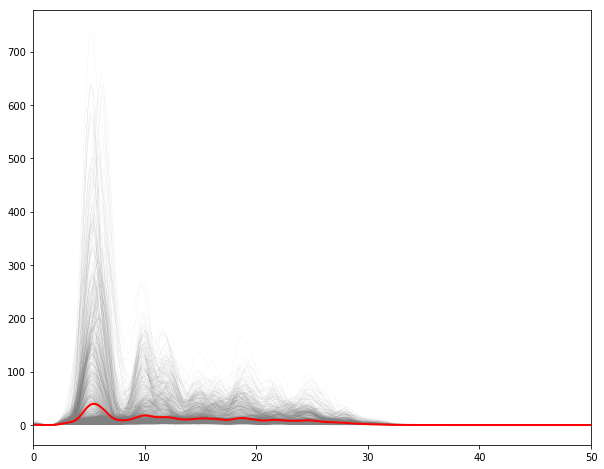

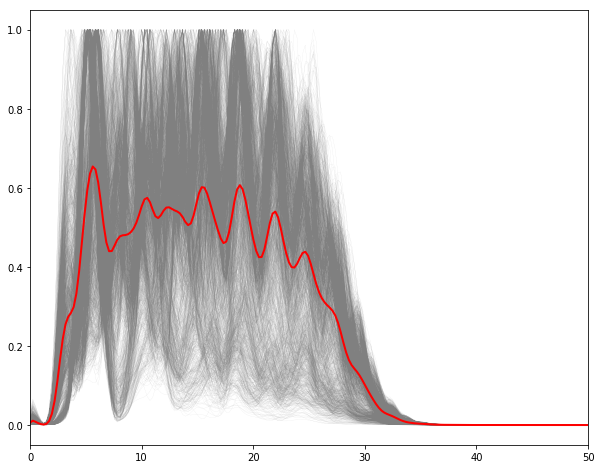

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

#load data

x = np.load('egms_total.npy') 

#compute the welch period. for each of the egms

pxx = []

for i in range(x.shape[0]):
    f,pxx_aux = signal.welch(x[i,:],fs = 500,nfft=2048,nperseg=512)
    pxx.append(pxx_aux)
    

pxx = np.asarray(pxx)

plt.figure(figsize = (10,8))
plt.plot(f,pxx.T,':',linewidth = 0.1,color = 'gray')
plt.xlim((0,50))
plt.plot(f,np.mean(pxx,axis=0),color = 'r',linewidth = 2)
#look at the frequency content of the data from the models

xx = np.max(pxx,axis=1)
pxx_n = pxx/xx[:,np.newaxis]

plt.figure(figsize = (10,8))
plt.plot(f,pxx_n.T,':',linewidth = 0.1,color = 'gray')
plt.xlim((0,50))
plt.plot(f,np.mean(pxx_n,axis=0),color = 'r',linewidth = 2)

Both plots show us that the band-pass nature of the simulation models goes from 10Hz up to 30 Hz. Assuming that the fundamental frequency is around 5 Hz. So If we filter the signl with a band-pass filter of 40-250 Hz is going to kill any information on the signal.

## Botterom - Smith preprocessing

In this section we are going to perform the preprocessing to obtain a suitable signal to estimate the dominant frequency.

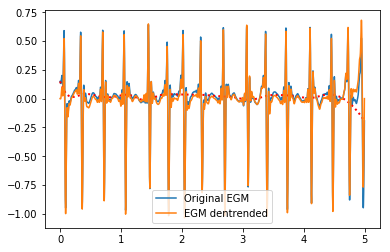

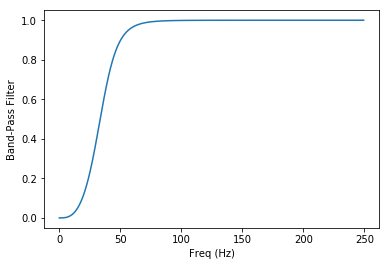

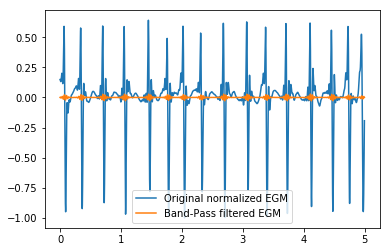

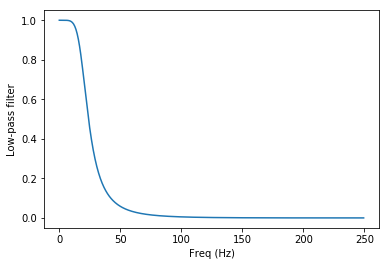

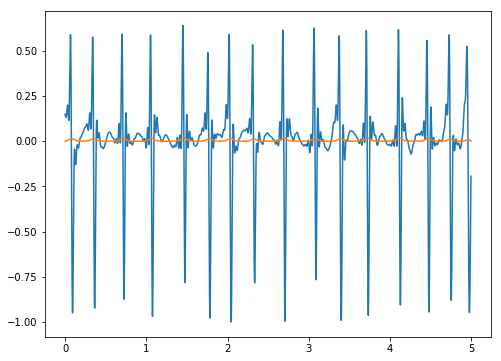

In [4]:
from freq_analysis import *

#try one example using default values for the botterom-smith

fs = 500

z_egm, Pz, fz = botterom_smith_df(x[0,:],fs,f2 = 249.99)


plt.figure(figsize = (8,6))
t = np.arange(len(x[0,:]))/fs
plt.plot(t,x[0,:]/np.max(np.abs(x[0,:])))
plt.plot(t,z_egm)

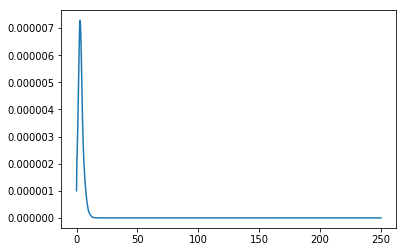

In [5]:
#spectral analysis

f,pxx = signal.welch(x[0,:]/np.max([x[0,:]]),fs = 500,nfft = 2048)

plt.figure()
#plt.plot(f,pxx)
plt.plot(fz,Pz)

If we adapt the band-pass filter to obtain a more suitable filtering signal

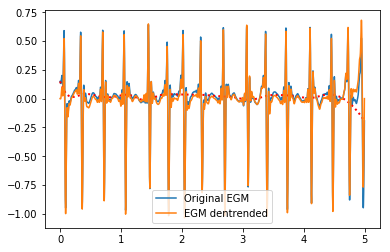

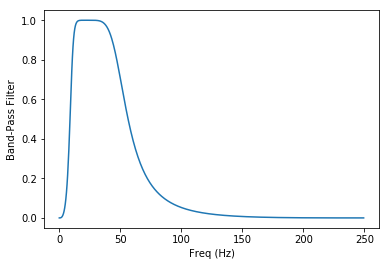

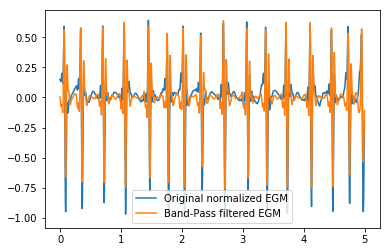

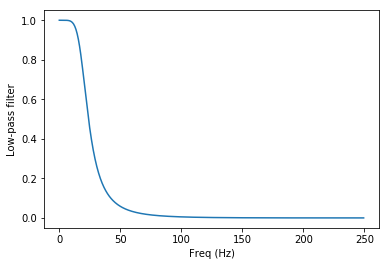

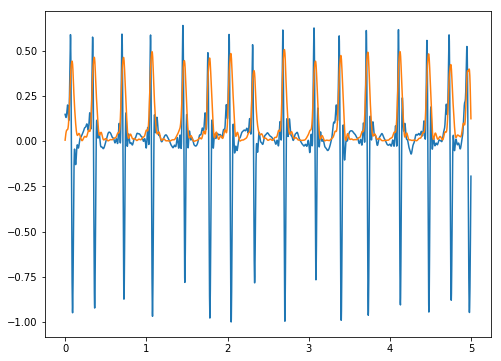

In [6]:
z_egm, Pz, fz = botterom_smith_df(x[0,:],fs,f1 =10,f2 = 50)


plt.figure(figsize = (8,6))
t = np.arange(len(x[0,:]))/fs
plt.plot(t,x[0,:]/np.max(np.abs(x[0,:])))
plt.plot(t,z_egm)

2.9296875


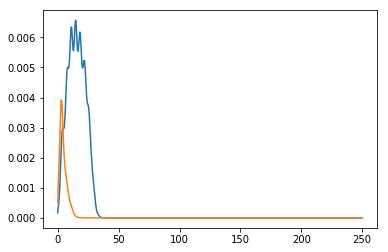

In [7]:
#spectral analysis

f,pxx = signal.welch(x[0,:]/np.max([x[0,:]]),fs = 500,nfft = 2048)

plt.figure()
plt.plot(f,pxx)
plt.plot(fz,Pz)

print(f[np.argmax(Pz)])

In [8]:
# Let's try the complete dataset
pz = []
z = []

for i in range(x.shape[0]):
    z_egm, Pz, fz = botterom_smith_df(x[i,:],fs,f1 =10,f2 = 50,plot_flag = False)
    pz.append(Pz)
    z.append(z_egm)
    

(2048, 1013)
(1013,)


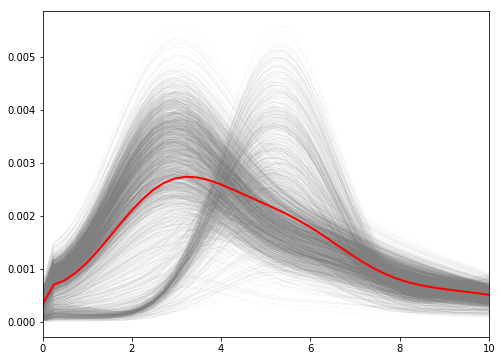

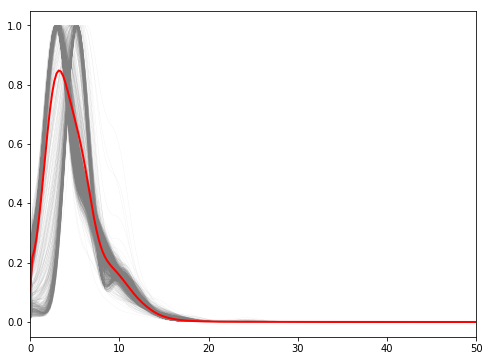

In [9]:
pz = np.asarray(pz)
print(pz.shape)
print(fz.shape)
pz = np.asarray(pz)

plt.figure(figsize = (8,6))
plt.plot(fz,pz.T,':',linewidth = 0.1,color = 'gray')
plt.xlim((0,10))
plt.plot(fz,np.mean(pz,axis=0),color = 'r',linewidth = 2)
#look at the frequency content of the data from the models

xx = np.max(pz,axis=1)
pz_n = pz/xx[:,np.newaxis]

plt.figure(figsize = (8,6))
plt.plot(fz,pz_n.T,':',linewidth = 0.1,color = 'gray')
plt.xlim((0,50))
plt.plot(fz,np.mean(pz_n,axis=0),color = 'r',linewidth = 2)


(2048,)


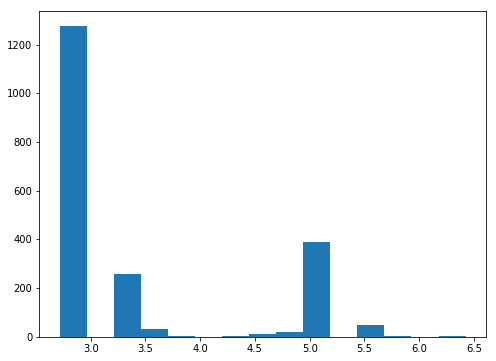

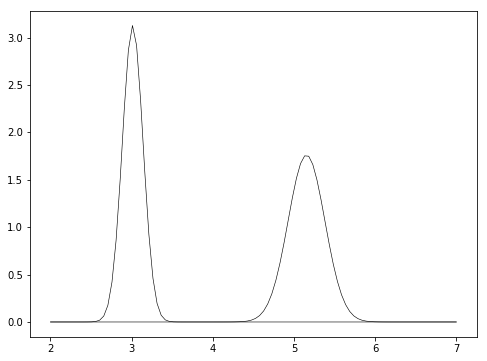

In [11]:
#finding df
df= []
for i in range(pz.shape[0]):
    idx_df = np.argmax(pz[i,fz<10])
    df_aux = fz[idx_df]
    df.append(df_aux)

plt.figure(figsize = (8,6))
plt.hist(df,bins = 15)

df = np.asarray(df)

#np.savetxt('df_raa.txt',df)

print(df.shape)
df_1 = df[df<4]
df_2 = df[df>4]

def gauss(x,mu,s_2):
    pdf = 1/(np.sqrt(2*np.pi*s_2)) * np.exp( -1/2* (x-mu)**2/s_2 )
    return pdf

x= np.linspace(2,7,100)
pdf1 = gauss(x,np.mean(df_1),np.var(df_1))
pdf2 = gauss(x,np.mean(df_2),np.var(df_2))
plt.figure(figsize = (8,6))
plt.plot(x,pdf1,color = 'k',linewidth = 0.6)
plt.plot(x,pdf2,color = 'k',linewidth = 0.6)